## In-depth  energy module behaviour
In this notebook, we set up graph with a single edge to demonstrate some basic functionality of the Energy module.
--> to to virtual environment opentnsimenv2!

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from pyproj import Geod
import shapely.geometry
from shapely.geometry import Point, LineString
from shapely.geometry.base import BaseGeometry
import logging

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime, time
import simpy
import opentnsim
from opentnsim import core as core_module
from opentnsim.energy import mixins as energy_module
from opentnsim.graph import mixins as graph_module
from opentnsim import output as output_module
from opentnsim.core import vessel_properties as vessel_module
from opentnsim import vessel_traffic_service as vessel_traffic_service_module

# package(s) needed for inspecting the output
import numpy as np
import pandas as pd

# package(s) needed for plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.1


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel",
    (
        opentnsim.energy.mixins.ConsumesEnergy,
        opentnsim.core.Identifiable,  # allows to give the object a name and a random ID,
        opentnsim.core.Movable,  # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.vessel_properties.VesselProperties,
        opentnsim.core.ExtraMetadata,
    ),
    {},
)

#### 2. Create graph
Next we create a network (a graph) along which the vessel can move. This case we create a single edge of 100 km exactly.

In [3]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [4]:
# starting point (longitude, latitude)
lon0, lat0 = 0, 0

# compute the other point 100 km East from Point 0
lon1, lat1, _ = geod.fwd(lon0, lat0, 90, 100000)  # East from Point 0

# define nodes with their geographic coordinates
coords = {
    "0": (lon0, lat0),
    "1": (lon1, lat1),
}

In [5]:
# create list of edges
edges = [("0", "1"), ("1", "0")]  # bi-directional edge

In [6]:
# create a directed graph
FG = nx.DiGraph()

# add nodes
for name, coord in coords.items():
    FG.add_node(name, geometry=Point(coord[0], coord[1]))

# add edges
for edge in edges:
    FG.add_edge(edge[0], edge[1], weight=1)

In [7]:
# Force length_m to be 100km 
FG.edges["0", "1"]["Info"] = {"length_m": 100000}
FG.edges["1", "0"]["Info"] = {"length_m": 100000}

In [8]:
# Printing the data per edge to see what the names are. Check if there is water depth info
for u, v, data in FG.edges(data=True):
    print (u, "->", v)
    print(data)
    # break

0 -> 1
{'weight': 1, 'Info': {'length_m': 100000}}
1 -> 0
{'weight': 1, 'Info': {'length_m': 100000}}


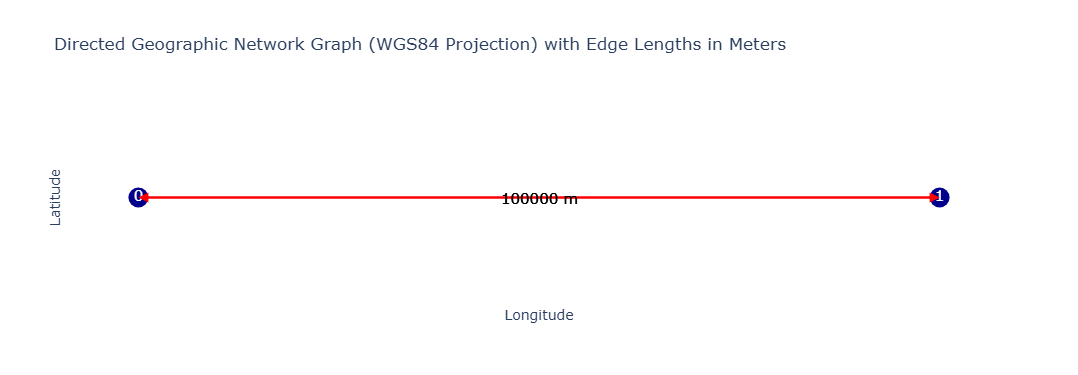

In [9]:
graph_module.plot_graph(FG)

#### 3. Run simulation

In [10]:
def mission(
    FG,
    GeneralDepth,
    name,
    origin,
    destination,
    vessel_type,
    L,
    B,
    T,
    v,
    safety_margin,
    h_squat,
    P_installed,
    P_tot_given,
    bulbous_bow,
    karpov_correction,
    P_hotel_perc,
    P_hotel,
    x,
    L_w,
    C_B,
    C_year,
    arrival_time,
):
    """Method that defines the mission of the vessel.

    In this case:
        a basic vessel moves along the given route
    """

    # start simpy environment
    simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
    env = simpy.Environment(initial_time=simulation_start.timestamp())
    env.epoch = simulation_start  # Start simpy environment

    # add graph to environment
    FG.edges["0", "1"]["Info"] = {"GeneralDepth": GeneralDepth}
    FG.edges["1", "0"]["Info"] = {"GeneralDepth": GeneralDepth}
    # FG.edges["0", "1"] = {"GeneralDepth": GeneralDepth}
    # FG.edges["1", "0"] = {"GeneralDepth": GeneralDepth}

    env.graph = FG

    # TODO: make a mission with all inputs (now some are
    vessel = Vessel(
        **{
            "env": env,
            "name": name,
            "origin": origin,
            "destination": destination,
            "type": vessel_type,
            "L": L,  # m
            "B": B,  # m
            "T": T,  # m
            "v": v,  # m/s None: calculate this value based on P_tot_given
            "safety_margin": safety_margin,  # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m
            "h_squat": h_squat,  # if consider the ship squatting while moving, set to True, otherwise set to False
            "P_installed": P_installed,  # kW
            "P_tot_given": P_tot_given,  # kW None: calculate this value based on speed
            "bulbous_bow": bulbous_bow,  # if a vessel has no bulbous_bow, set to False; otherwise set to True.
            "karpov_correction": karpov_correction,  # if True, wave and residual resistances are calculated with corrected v
            "P_hotel_perc": P_hotel_perc,  # 0: all power goes to propulsion
            "P_hotel": P_hotel,  # None: calculate P_hotel from percentage
            "x": x,  # number of propellers
            "C_B": C_B,  # block coefficient
            "L_w": L_w,  # wheight class of the ship
            "C_year": C_year,  # engine build year
            "arrival_time": arrival_time,
            "geometry": FG.nodes["0"]["geometry"],
            "route": nx.dijkstra_path(env.graph, source=origin, target=destination),
        }
    )
    env.process(vessel.move())

    env.run()

    # TODO: replace with the event table approach
    energycalculation = energy_module.EnergyCalculation(vessel.env.graph, vessel)
    energycalculation.calculate_energy_consumption()

    df = pd.DataFrame.from_dict(energycalculation.energy_use)
    df["fuel_kg_per_km"] = (df["total_diesel_consumption_ICE_mass"] / 1000) / (df["distance"] / 1000)
    df["CO2_g_per_km"] = (df["total_emission_CO2"]) / (df["distance"] / 1000)
    df["PM10_g_per_km"] = (df["total_emission_PM10"]) / (df["distance"] / 1000)
    df["NOx_g_per_km"] = (df["total_emission_NOX"]) / (df["distance"] / 1000)

    return df, vessel

#### 4.1 Show the effects of vessel velocity on resistance, power and energy
We run above predefined mission for a range of velocities

In [11]:
v_stream2020_l = 2.51
v_stream2020_u = 3.07
v_stream2016_l = 2.78
v_stream2016_u = 4.76
v_bolt_l       = 4.59
v_bolt_u       = 5.14

In [39]:
# LOADED VESSEL
# generate a range of vessel speeds
velocity_range = list(np.arange(0.01, 6, 0.01))

# generate vessels that sail the edge for the given range of vessel speeds
dfs = []
vessels = []

for v in velocity_range:
    # execute predefined mission
    df, vessel1 = mission(
        FG=FG,
        GeneralDepth=6,
        name="Vessel",
        origin="0",
        destination="1",
        vessel_type="inland vessel M8 loaded",
        L=110,  # m M8
        B=11.4,  # m M8 
        T=3.5,  # m M8 loaded: 3.5m, empty 1.8m
        v=v,  # m/s None: calculate this value based on P_tot_given
        safety_margin=0.2,  # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m
        h_squat=False,  # if consider the ship squatting while moving, set to True, otherwise set to False
        P_installed=1750,  # kW
        P_tot_given=None,  # kW None: calculate this value based on speed
        bulbous_bow=False,  # if a vessel has no bulbous_bow, set to False; otherwise set to True.
        karpov_correction=True,
        P_hotel_perc=0.05,  # 0: all power goes to propulsion
        P_hotel=None,  # None: calculate P_hotel from percentage
        x=2,  # number of propellers
        C_B=0.85,  # - block coefficient
        L_w=3,  # weight class of the ship
        C_year=1990,  # engine construction yea
        arrival_time=datetime.datetime(2024, 1, 1, 0, 0, 0),
    )

    dfs.append(df)
    vessels.append(vessel1)

In [40]:
# collect values to plot (resistances from list of vessels, power and energy from the list of dataframes)
R_tot = []
R_f_one_k1 = []
R_APP = []
R_W = []
R_res = []
P_tot = []
total_energy = []
for index, df in enumerate(dfs):
    R_tot.append(vessels[index].R_tot)
    R_f_one_k1.append(vessels[index].R_f_one_k1)
    R_APP.append(vessels[index].R_APP)
    R_W.append(vessels[index].R_W)
    R_res.append(vessels[index].R_res)
    P_tot.append(df.P_tot.values[0])
    total_energy.append(df.total_energy.values[0])

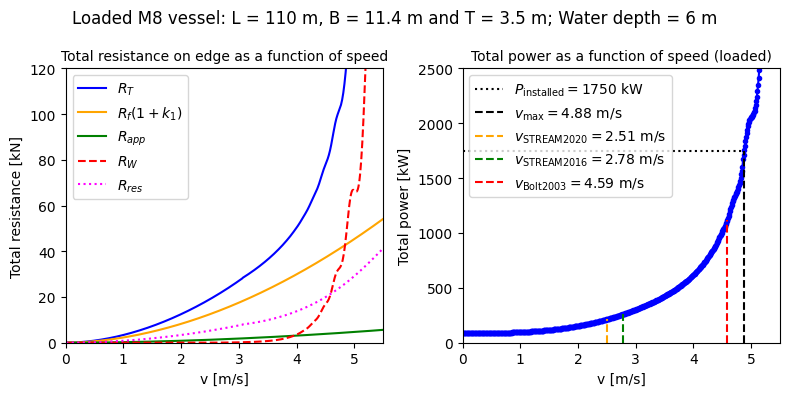

In [41]:
# LOADED PLOT
# change km/h to m/s, change to M8 loaded/empty -> needs to be changed in vessel object ok 
# Generate plot
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# plot resistance components as a function of vessel speed
axes[0].plot([i for i in velocity_range], R_tot, "-", c="blue", mfc="blue", mec="blue", markersize=3, label="$R_T$")
axes[0].plot(
    [i for i in velocity_range], R_f_one_k1, "-", c="orange", mfc="orange", mec="orange", markersize=3, label="$R_f (1+k_1)$"
)
axes[0].plot([i for i in velocity_range], R_APP, "-", c="green", mfc="green", mec="green", markersize=3, label="$R_{app}$")
axes[0].plot([i for i in velocity_range], R_W, "--", c="red", mfc="red", mec="red", markersize=3, label="$R_W$")
axes[0].plot(
    [i for i in velocity_range], R_res, ":", c="magenta", mfc="magenta", mec="magenta", markersize=3, label="$R_{res}$"
)

axes[0].axis([0, 5.5, 0, 120])
axes[0].set_xlabel("v [m/s]")
axes[0].set_ylabel("Total resistance [kN]")
axes[0].set_title("Total resistance on edge as a function of speed", fontsize=10)
axes[0].legend(loc="upper left")

# --- Power plot ---
axes[1].plot(velocity_range, P_tot, "-o", c="blue", markersize=3)
axes[1].axis([0, 5.5, 0, 2500])

P_installed = 1750
Pmax = axes[1].get_ylim()[1]

# Installed power → v_max
v_max = np.interp(P_installed, P_tot, velocity_range)
yfrac_inst, xfrac_inst = P_installed / Pmax, v_max / axes[1].get_xlim()[1]

# Installed power line (stops at intersection)
axes[1].axhline(P_installed, 0, xfrac_inst, c="black", ls=":", lw=1.5,
                label=r"$P_{\mathrm{installed}} = 1750\ \mathrm{kW}$")

# v_max line (stops at blue curve)
axes[1].axvline(v_max, 0, yfrac_inst, c="black", ls="--", lw=1.5,
                label=rf"$v_{{\max}} = {v_max:.2f}\ \mathrm{{m/s}}$")

# STREAM / Bolt speeds — each stops at ITS OWN power level
for v, c, name in [
    (v_stream2020_l, "orange", "STREAM2020"),
    (v_stream2016_l, "green",  "STREAM2016"),
    (v_bolt_l,       "red",    "Bolt2003"),
]:
    P_v = np.interp(v, velocity_range, P_tot)
    axes[1].axvline(v, 0, P_v/Pmax, c=c, ls="--", lw=1.5,
                    label=rf"$v_{{\mathrm{{{name}}}}} = {v:.2f}\ \mathrm{{m/s}}$")

axes[1].axis([0, 5.5, 0, 2500])
axes[1].set_xlabel("v [m/s]")
axes[1].set_ylabel("Total power [kW]")
axes[1].set_title("Total power as a function of speed (loaded)", fontsize=10)
axes[1].legend(loc="upper left")

# # plot total energy needed to pass the edge as a function of vessel speed
# axes[2].plot([i for i in velocity_range], total_energy, "-o", c="blue", mfc="blue", mec="blue", markersize=3)

# axes[2].axis([0, 5.5, 0, 25000])
# axes[2].set_xlabel("v [m/s]")
# axes[2].set_ylabel("Total energy [kWh]")
# axes[2].set_title("Total energy on edge as a function of speed", fontsize=10)

# Add a super title
fig.suptitle(
    "Loaded M8 vessel: L = {} m, B = {} m and T = {} m; Water depth = {} m".format(
        vessels[0].L, vessels[0].B, vessels[0].T, vessels[0].env.graph.edges[("0", "1")]["Info"]["GeneralDepth"]
    ),
    fontsize=12,
)

# Adjust layout to bring the title closer to the plots
fig.tight_layout(rect=[0, 0, 1, 1])  # Adjust the top margin (last value)

plt.show()

In [15]:
# UNLOADED VESSEL
# generate a range of vessel speeds
velocity_range = list(np.arange(0.01, 6, 0.01))

# generate vessels that sail the edge for the given range of vessel speeds
dfs = []
vessels = []

for v in velocity_range:
    # execute predefined mission
    df, vessel2 = mission(
        FG=FG,
        GeneralDepth=6,
        name="Vessel2",
        origin="0",
        destination="1",
        vessel_type="inland vessel M8 unloaded",
        L=110,  # m M8
        B=11.4,  # m M8 
        T=1.8,  # m M8 loaded: 3.5m, empty 1.8m
        v=v,  # m/s None: calculate this value based on P_tot_given
        safety_margin=0.2,  # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m
        h_squat=False,  # if consider the ship squatting while moving, set to True, otherwise set to False
        P_installed=1750,  # kW
        P_tot_given=None,  # kW None: calculate this value based on speed
        bulbous_bow=False,  # if a vessel has no bulbous_bow, set to False; otherwise set to True.
        karpov_correction=True,
        P_hotel_perc=0.05,  # 0: all power goes to propulsion
        P_hotel=None,  # None: calculate P_hotel from percentage
        x=2,  # number of propellers
        C_B=0.85,  # - block coefficient
        L_w=3,  # weight class of the ship
        C_year=1990,  # engine construction yea
        arrival_time=datetime.datetime(2024, 1, 1, 0, 0, 0),
    )

    dfs.append(df)
    vessels.append(vessel2)

In [16]:
# collect values to plot (resistances from list of vessels, power and energy from the list of dataframes)
R_tot = []
R_f_one_k1 = []
R_APP = []
R_W = []
R_res = []
P_tot = []
total_energy = []
for index, df in enumerate(dfs):
    R_tot.append(vessels[index].R_tot)
    R_f_one_k1.append(vessels[index].R_f_one_k1)
    R_APP.append(vessels[index].R_APP)
    R_W.append(vessels[index].R_W)
    R_res.append(vessels[index].R_res)
    P_tot.append(df.P_tot.values[0])
    total_energy.append(df.total_energy.values[0])

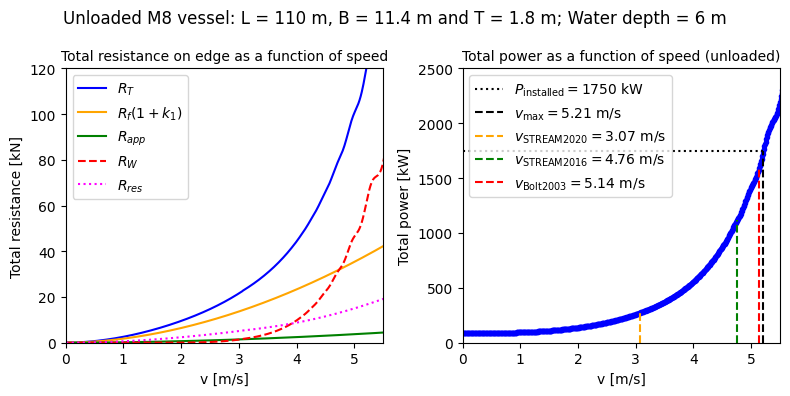

In [17]:
# UNLOADED PLOT 
# change km/h to m/s, change to M8 loaded/empty -> needs to be changed in vessel object ok 
# Generate plot
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# plot resistance components as a function of vessel speed
axes[0].plot([i for i in velocity_range], R_tot, "-", c="blue", mfc="blue", mec="blue", markersize=3, label="$R_T$")
axes[0].plot(
    [i for i in velocity_range], R_f_one_k1, "-", c="orange", mfc="orange", mec="orange", markersize=3, label="$R_f (1+k_1)$"
)
axes[0].plot([i for i in velocity_range], R_APP, "-", c="green", mfc="green", mec="green", markersize=3, label="$R_{app}$")
axes[0].plot([i for i in velocity_range], R_W, "--", c="red", mfc="red", mec="red", markersize=3, label="$R_W$")
axes[0].plot(
    [i for i in velocity_range], R_res, ":", c="magenta", mfc="magenta", mec="magenta", markersize=3, label="$R_{res}$"
)

axes[0].axis([0, 5.5, 0, 120])
axes[0].set_xlabel("v [m/s]")
axes[0].set_ylabel("Total resistance [kN]")
axes[0].set_title("Total resistance on edge as a function of speed", fontsize=10)
axes[0].legend(loc="upper left")

# --- Power plot ---
axes[1].plot(velocity_range, P_tot, "-o", c="blue", markersize=3)
axes[1].axis([0, 5.5, 0, 2500])

P_installed = 1750
Pmax = axes[1].get_ylim()[1]

# Installed power → v_max
v_max = np.interp(P_installed, P_tot, velocity_range)
yfrac_inst, xfrac_inst = P_installed / Pmax, v_max / axes[1].get_xlim()[1]

# Installed power line (stops at intersection)
axes[1].axhline(P_installed, 0, xfrac_inst, c="black", ls=":", lw=1.5,
                label=r"$P_{\mathrm{installed}} = 1750\ \mathrm{kW}$")

# v_max line (stops at blue curve)
axes[1].axvline(v_max, 0, yfrac_inst, c="black", ls="--", lw=1.5,
                label=rf"$v_{{\max}} = {v_max:.2f}\ \mathrm{{m/s}}$")

# STREAM / Bolt speeds — each stops at ITS OWN power level
for v, c, name in [
    (v_stream2020_u, "orange", "STREAM2020"),
    (v_stream2016_u, "green",  "STREAM2016"),
    (v_bolt_u,       "red",    "Bolt2003"),
]:
    P_v = np.interp(v, velocity_range, P_tot)
    axes[1].axvline(v, 0, P_v/Pmax, c=c, ls="--", lw=1.5,
                    label=rf"$v_{{\mathrm{{{name}}}}} = {v:.2f}\ \mathrm{{m/s}}$")

axes[1].axis([0, 5.5, 0, 2500])
axes[1].set_xlabel("v [m/s]")
axes[1].set_ylabel("Total power [kW]")
axes[1].set_title("Total power as a function of speed (unloaded)", fontsize=10)
axes[1].legend(loc="upper left")

# # plot total energy needed to pass the edge as a function of vessel speed
# axes[2].plot([i for i in velocity_range], total_energy, "-o", c="blue", mfc="blue", mec="blue", markersize=3)

# axes[2].axis([0, 5.5, 0, 25000])
# axes[2].set_xlabel("v [m/s]")
# axes[2].set_ylabel("Total energy [kWh]")
# axes[2].set_title("Total energy on edge as a function of speed", fontsize=10)

# Add a super title
fig.suptitle(
    "Unloaded M8 vessel: L = {} m, B = {} m and T = {} m; Water depth = {} m".format(
        vessels[0].L, vessels[0].B, vessels[0].T, vessels[0].env.graph.edges[("0", "1")]["Info"]["GeneralDepth"]
    ),
    fontsize=12,
)

# Adjust layout to bring the title closer to the plots
fig.tight_layout(rect=[0, 0, 1, 1])  # Adjust the top margin (last value)

plt.show()

Panel 1 in the figure above, corresponds to Part IV - Figure 5.4 in Van Koningsveld et al (2023), https://doi.org/10.5074/T.2021.004. Panel 2 shows how the R_tot from Panel 1 is converted to P_tot, multiplying with v and using various efficiency factors. Panel 3 shows the total energy that is required to pass the 100 km long edge. This total energy is derived by multiplying the P_tot with the time it takes to pass the edge. For very low v's the R_tot is low, but it also takes long to pass the edge. For high v's the R_tot escalates, but the time to pass the edge reduces.

#### 4.4 Show the effects of changing water depth (WIP)
We will now sail the same path with the same vessel at a given speed, and change the water depths in steps. First with 'karpov_correction' set to False.

In [18]:
# COMBINED ZHENG + KARPOV
# generate a range of depths
depth_list = list(np.arange(4, 15, 0.1))

# generate vessels that sail the edge for the given range of vessel speeds
dfs_lz = []
vessels_lz = []
dfs_uz = []
vessels_uz = []
dfs_lk = []
vessels_lk = []
dfs_uk = []
vessels_uk = []

for depth in depth_list:
    df_lz, vessel_lz = mission(
        FG=FG,
        GeneralDepth=depth,
        name="Vessel",
        origin="0",
        destination="1",
        vessel_type="inland vessel M8 loaded Zheng",
        L=110,  # m
        B=11.4,  # m
        T=3.5,  # m
        # v=2.51,  # m/s None: calculate this value based on P_tot_given
        v=4.0,  # m/s None: calculate this value based on P_tot_given
        safety_margin=0.2,  # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m
        h_squat=False,  # if consider the ship squatting while moving, set to True, otherwise set to False
        P_installed=1750,  # kW
        P_tot_given=None,  # kW None: calculate this value based on speed
        bulbous_bow=False,  # if a vessel has no bulbous_bow, set to False; otherwise set to True.
        karpov_correction=False,
        P_hotel_perc=0.05,  # 0: all power goes to propulsion
        P_hotel=None,  # None: calculate P_hotel from percentage
        x=2,  # number of propellers
        C_B=0.85,  # - block coefficient
        L_w=3,  # weight class of the ship
        C_year=1990,  # engine construction yea
        arrival_time=datetime.datetime(2024, 1, 1, 0, 0, 0),
    )
    df_uz, vessel_uz = mission(
        FG=FG,
        GeneralDepth=depth,
        name="Vessel",
        origin="0",
        destination="1",
        vessel_type="inland vessel M8 unloaded Zheng",
        L=110,  # m
        B=11.4,  # m
        T=1.8,  # m
        # v=3.07,  # m/s None: calculate this value based on P_tot_given
        v=4.0,
        safety_margin=0.2,  # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m
        h_squat=False,  # if consider the ship squatting while moving, set to True, otherwise set to False
        P_installed=1750,  # kW
        P_tot_given=None,  # kW None: calculate this value based on speed
        bulbous_bow=False,  # if a vessel has no bulbous_bow, set to False; otherwise set to True.
        karpov_correction=False,
        P_hotel_perc=0.05,  # 0: all power goes to propulsion
        P_hotel=None,  # None: calculate P_hotel from percentage
        x=2,  # number of propellers
        C_B=0.85,  # - block coefficient
        L_w=3,  # weight class of the ship
        C_year=1990,  # engine construction yea
        arrival_time=datetime.datetime(2024, 1, 1, 0, 0, 0),
    )
    df_lk, vessel_lk = mission(
        FG=FG,
        GeneralDepth=depth,
        name="Vessel",
        origin="0",
        destination="1",
        vessel_type="inland vessel M8 loaded Karpov",
        L=110,  # m
        B=11.4,  # m
        T=3.5,  # m
        # v=2.51,  # m/s None: calculate this value based on P_tot_given
        v=4.0,
        safety_margin=0.2,  # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m
        h_squat=False,  # if consider the ship squatting while moving, set to True, otherwise set to False
        P_installed=1750,  # kW
        P_tot_given=None,  # kW None: calculate this value based on speed
        bulbous_bow=False,  # if a vessel has no bulbous_bow, set to False; otherwise set to True.
        karpov_correction=True,
        P_hotel_perc=0.05,  # 0: all power goes to propulsion
        P_hotel=None,  # None: calculate P_hotel from percentage
        x=2,  # number of propellers
        C_B=0.85,  # - block coefficient
        L_w=3,  # weight class of the ship
        C_year=1990,  # engine construction yea
        arrival_time=datetime.datetime(2024, 1, 1, 0, 0, 0),
    )
    df_uk, vessel_uk = mission(
        FG=FG,
        GeneralDepth=depth,
        name="Vessel",
        origin="0",
        destination="1",
        vessel_type="inland vessel M8 unloaded Karpov",
        L=110,  # m
        B=11.4,  # m
        T=1.8,  # m
        # v=3.07,  # m/s None: calculate this value based on P_tot_given
        v=4.0,
        safety_margin=0.2,  # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m
        h_squat=False,  # if consider the ship squatting while moving, set to True, otherwise set to False
        P_installed=1750,  # kW
        P_tot_given=None,  # kW None: calculate this value based on speed
        bulbous_bow=False,  # if a vessel has no bulbous_bow, set to False; otherwise set to True.
        karpov_correction=True,
        P_hotel_perc=0.05,  # 0: all power goes to propulsion
        P_hotel=None,  # None: calculate P_hotel from percentage
        x=2,  # number of propellers
        C_B=0.85,  # - block coefficient
        L_w=3,  # weight class of the ship
        C_year=1990,  # engine construction yea
        arrival_time=datetime.datetime(2024, 1, 1, 0, 0, 0),
    )

    dfs_lz.append(df_lz)
    vessels_lz.append(vessel_lz)
    dfs_uz.append(df_uz)
    vessels_uz.append(vessel_uz)
    dfs_lk.append(df_lk)
    vessels_lk.append(vessel_lk)
    dfs_uk.append(df_uk)
    vessels_uk.append(vessel_uk)

In [19]:
# collect values to plot
P_tot_values_lz = []
for index, df_lz in enumerate(dfs_lz):
    P_tot_values_lz.append(df_lz.P_tot.values[0])
    
P_tot_values_uz = []
for index, df_uz in enumerate(dfs_uz):
    P_tot_values_uz.append(df_uz.P_tot.values[0])

# collect values to plot
P_tot_values_lk = []
for index, df_lk in enumerate(dfs_lk):
    P_tot_values_lk.append(df_lk.P_tot.values[0])
    
P_tot_values_uk = []
for index, df_uk in enumerate(dfs_uk):
    P_tot_values_uk.append(df_uk.P_tot.values[0])

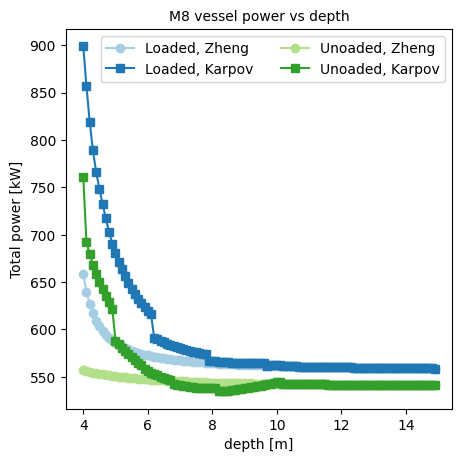

LZ P_tot value for the largest depth 558.63 kW
UZ P_tot value for the largest depth 540.93 kW
LK P_tot value for the largest depth 558.63 kW
UK P_tot value for the largest depth 540.93 kW


In [20]:
# Compute depth array and vessel parameters
depth_array = np.array(depth_list)

# --- Plot settings ---
fig_width_cm = 12
fig_height_cm = 12
fig_size_in = (fig_width_cm / 2.54, fig_height_cm / 2.54)


fig, ax = plt.subplots(figsize=fig_size_in)

# ax.plot(depth_array,np.array(P_tot_values_lz),"o-",label=f"Loaded: T = {vessels_lz[0].T} m, v = {vessels_lz[0].v} m/s (Zheng)")

# ax.plot(depth_array,np.array(P_tot_values_lz),"o-",label=f"Loaded: T = {vessels_lz[0].T} m, v = {vessels_lz[0].v} m/s (Zheng)")
# ax.plot(depth_array,np.array(P_tot_values_uz),"o-",label=f"Unoaded: T = {vessels_uz[0].T} m, v = {vessels_uz[0].v} m/s (Zheng)")
# ax.plot(depth_array,np.array(P_tot_values_lk),"s-",label=f"Loaded: T = {vessels_lk[0].T} m, v = {vessels_lk[0].v} m/s (Karpov)")
# ax.plot(depth_array,np.array(P_tot_values_uk),"s-",label=f"Unoaded: T = {vessels_uk[0].T} m, v = {vessels_uk[0].v} m/s (Karpov)")

ax.plot(depth_array,np.array(P_tot_values_lz),"o-", c="#a6cee3", label=f"Loaded, Zheng")
ax.plot(depth_array,np.array(P_tot_values_lk),"s-", c="#1f78b4", label=f"Loaded, Karpov")
ax.plot(depth_array,np.array(P_tot_values_uz),"o-", c="#b2df8a", label=f"Unoaded, Zheng")
ax.plot(depth_array,np.array(P_tot_values_uk),"s-", c="#33a02c", label=f"Unoaded, Karpov")


ax.set_xlabel("depth [m]")
ax.set_ylabel("Total power [kW]")
ax.set_title(
    f"M8 vessel power vs depth",
    fontsize=10,
)
# ax.legend(loc="upper right")
ax.legend(ncol=2)
# ax.grid(False)

plt.tight_layout()
plt.show()


print("LZ P_tot value for the largest depth {:.2f} kW".format(P_tot_values_lz[-1]))
print("UZ P_tot value for the largest depth {:.2f} kW".format(P_tot_values_uz[-1]))
print("LK P_tot value for the largest depth {:.2f} kW".format(P_tot_values_lk[-1]))
print("UK P_tot value for the largest depth {:.2f} kW".format(P_tot_values_uk[-1]))

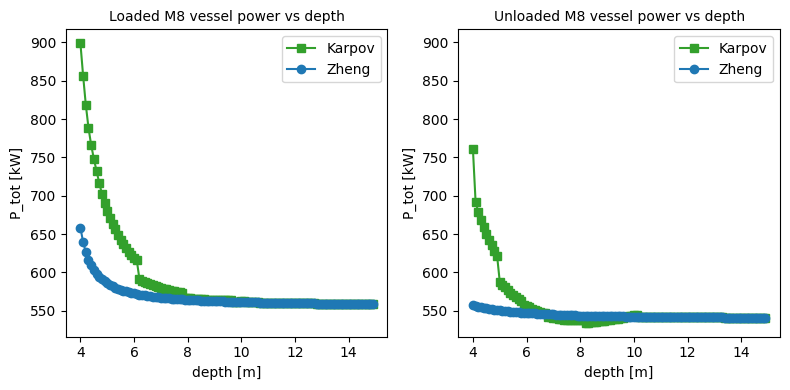

LZ P_tot value for the largest depth 558.63 kW
UZ P_tot value for the largest depth 540.93 kW
LK P_tot value for the largest depth 558.63 kW
UK P_tot value for the largest depth 540.93 kW


In [21]:
# Compute depth array and vessel parameters
depth_array = np.array(depth_list)

# --- Plot settings ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# fig_width_cm = 12
# fig_height_cm = 12
# fig_size_in = (fig_width_cm / 2.54, fig_height_cm / 2.54)


# fig, ax = plt.subplots(figsize=fig_size_in)

# ax.plot(depth_array,np.array(P_tot_values_lz),"o-",label=f"Loaded: T = {vessels_lz[0].T} m, v = {vessels_lz[0].v} m/s (Zheng)")

# ax.plot(depth_array,np.array(P_tot_values_lz),"o-",label=f"Loaded: T = {vessels_lz[0].T} m, v = {vessels_lz[0].v} m/s (Zheng)")
# ax.plot(depth_array,np.array(P_tot_values_uz),"o-",label=f"Unoaded: T = {vessels_uz[0].T} m, v = {vessels_uz[0].v} m/s (Zheng)")
# ax.plot(depth_array,np.array(P_tot_values_lk),"s-",label=f"Loaded: T = {vessels_lk[0].T} m, v = {vessels_lk[0].v} m/s (Karpov)")
# ax.plot(depth_array,np.array(P_tot_values_uk),"s-",label=f"Unoaded: T = {vessels_uk[0].T} m, v = {vessels_uk[0].v} m/s (Karpov)")

axes[0].plot(depth_array,np.array(P_tot_values_lk),"s-", c="#33a02c", label=f"Karpov")
axes[0].plot(depth_array,np.array(P_tot_values_lz),"o-", c="#1f78b4", label=f"Zheng")
axes[0].set_xlabel("depth [m]")
axes[0].set_ylabel("P_tot [kW]")
axes[0].set_title(
    f"Loaded M8 vessel power vs depth",
    fontsize=10,
)
axes[0].legend()

axes[1].plot(depth_array,np.array(P_tot_values_uk),"s-", c="#33a02c", label=f"Karpov")
axes[1].plot(depth_array,np.array(P_tot_values_uz),"o-", c="#1f78b4", label=f"Zheng")
axes[1].set_xlabel("depth [m]")
# axes[1].set_ylim(550,900)
axes[1].tick_params(axis="y", labelleft=True)
axes[1].set_ylabel("P_tot [kW]")
axes[1].set_title(
    f"Unloaded M8 vessel power vs depth",
    fontsize=10,
)
axes[1].legend()

# ax.legend(loc="upper right")
# ax.grid(False)

plt.tight_layout()
plt.show()


print("LZ P_tot value for the largest depth {:.2f} kW".format(P_tot_values_lz[-1]))
print("UZ P_tot value for the largest depth {:.2f} kW".format(P_tot_values_uz[-1]))
print("LK P_tot value for the largest depth {:.2f} kW".format(P_tot_values_lk[-1]))
print("UK P_tot value for the largest depth {:.2f} kW".format(P_tot_values_uk[-1]))

The correction by Zheng focuses on the friction resistance and involves two 'classes'. On the one hand a modified V_B that is used in the C_f calculation (where shallow is defined as h_0/T <= 4), and on the other a modified C_f (where shallow is defined as (h_0 - T)/L <= 1). The plot coloring shows in which part of the plot which conditions apply. Going from one condition to the next produces a small discontinuity

Now with 'karpov_correction' set to True.

In [22]:
# COMBINED KARPOV
# generate a range of depths
depth_list = list(np.arange(4, 15, 0.1))

# generate vessels that sail the edge for the given range of vessel speeds
dfs_l = []
vessels_l = []
dfs_u = []
vessels_u = []

for depth in depth_list:
    # execute predefined mission
    df_l, vessel_l = mission(
        FG=FG,
        GeneralDepth=depth,
        name="Vessel",
        origin="0",
        destination="1",
        vessel_type="inland vessel M8 loaded",
        L=110,  # m
        B=11.4,  # m
        T=3.5,  # m
        v=2.51,  # m/s None: calculate this value based on P_tot_given
        safety_margin=0.2,  # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m
        h_squat=False,  # if consider the ship squatting while moving, set to True, otherwise set to False
        P_installed=1750,  # kW
        P_tot_given=None,  # kW None: calculate this value based on speed
        bulbous_bow=False,  # if a vessel has no bulbous_bow, set to False; otherwise set to True.
        karpov_correction=True,
        P_hotel_perc=0.05,  # 0: all power goes to propulsion
        P_hotel=None,  # None: calculate P_hotel from percentage
        x=2,  # number of propellers
        C_B=0.85,  # - block coefficient
        L_w=3,  # weight class of the ship
        C_year=1990,  # engine construction yea
        arrival_time=datetime.datetime(2024, 1, 1, 0, 0, 0),
    )
    df_u, vessel_u = mission(
        FG=FG,
        GeneralDepth=depth,
        name="Vessel",
        origin="0",
        destination="1",
        vessel_type="inland vessel M8 unloaded",
        L=110,  # m
        B=11.4,  # m
        T=1.8,  # m
        v=3.07,  # m/s None: calculate this value based on P_tot_given
        safety_margin=0.2,  # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m
        h_squat=False,  # if consider the ship squatting while moving, set to True, otherwise set to False
        P_installed=1750,  # kW
        P_tot_given=None,  # kW None: calculate this value based on speed
        bulbous_bow=False,  # if a vessel has no bulbous_bow, set to False; otherwise set to True.
        karpov_correction=True,
        P_hotel_perc=0.05,  # 0: all power goes to propulsion
        P_hotel=None,  # None: calculate P_hotel from percentage
        x=2,  # number of propellers
        C_B=0.85,  # - block coefficient
        L_w=3,  # weight class of the ship
        C_year=1990,  # engine construction yea
        arrival_time=datetime.datetime(2024, 1, 1, 0, 0, 0),
    )

    dfs_l.append(df_l)
    vessels_l.append(vessel_l)
    dfs_u.append(df_u)
    vessels_u.append(vessel_u)

In [23]:
# collect values to plot
P_tot_values_l = []
for index, df_l in enumerate(dfs_l):
    P_tot_values_l.append(df_l.P_tot.values[0])
    
P_tot_values_u = []
for index, df_u in enumerate(dfs_u):
    P_tot_values_u.append(df_u.P_tot.values[0])

# collect values to plot
R_tot_values_l = []
for index, df_l in enumerate(dfs_l):
    R_tot_values_l.append(vessels_l[index].R_tot)
R_tot_values_u = []
for index, df_u in enumerate(dfs_u):
    R_tot_values_u.append(vessels_u[index].R_tot)

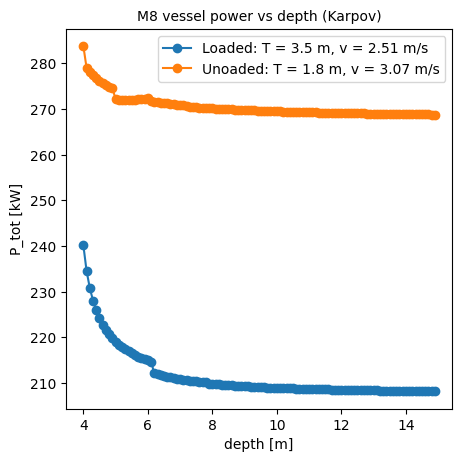

LOADED P_tot value for the largest depth 208.17 kW
LOADED R_tot value for the largest depth 18.18 kW
UNLOADED P_tot value for the largest depth 268.76 kW
UNLOADED R_tot value for the largest depth 22.32 kW


In [24]:
# COMBINED KARPOV PLOT
# Compute F_rh and h_ratio
depth_array = np.array(depth_list)

fig, ax = plt.subplots(figsize=fig_size_in)
# LOADED
ax.plot(depth_array,np.array(P_tot_values_l),"o-",label=f"Loaded: T = {vessels_l[0].T} m, v = {vessels_l[0].v} m/s")

# UNLOADED
ax.plot(depth_array,np.array(P_tot_values_u),"o-",label=f"Unoaded: T = {vessels_u[0].T} m, v = {vessels_u[0].v} m/s")
ax.set_xlabel("depth [m]")
ax.set_ylabel("P_tot [kW]")
ax.set_title(
    f"M8 vessel power vs depth (Karpov)",
    fontsize=10,
)
ax.legend()
# ax.grid(False)

plt.tight_layout()
plt.show()


print("LOADED P_tot value for the largest depth {:.2f} kW".format(P_tot_values_l[-1]))
print("LOADED R_tot value for the largest depth {:.2f} kW".format(R_tot_values_l[-1]))
print("UNLOADED P_tot value for the largest depth {:.2f} kW".format(P_tot_values_u[-1]))
print("UNLOADED R_tot value for the largest depth {:.2f} kW".format(R_tot_values_u[-1]))

The results show that while applying the Karpov correction factors, for deep water the estimated values for P_tot and R_tot are exactly the same. For shallower water the Karpov correction keeps the P_tot and R_tot value to similar values as the deeper water at first. But when the shallow water effects start to play a role, both the P_tot and R_tot values start to rise more quickly, and also to substantially higher values.